## Setup PP-OCRv5

In [1]:
# Install dependencies
!pip install -q paddlepaddle-gpu
!pip install -q paddleocr
!pip install -q scikit-image albumentations lmdb rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.1/231.1 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.0 MB/s eta 0:00:00
   ━━━━

In [2]:
!git clone https://github.com/PaddlePaddle/PaddleOCR.git
!pip install -q -r /kaggle/working/PaddleOCR/requirements.txt

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 308397, done.
remote: Counting objects: 100% (871/871), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 308397 (delta 754), reused 748 (delta 694), pack-reused 307526 (from 2)
Receiving objects: 100% (308397/308397), 1.63 GiB | 34.37 MiB/s, done.
Resolving deltas: 100% (243998/243998), done.


In [3]:
# Check if paddle installed properly
import paddle
paddle.utils.run_check()

Running verify PaddlePaddle program ... 


I0101 10:18:26.458877    25 program_interpreter.cc:212] New Executor is Running.
W0101 10:18:26.459339    25 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 12.8, Runtime API Version: 11.8
W0101 10:18:26.475239    25 gpu_resources.cc:164] device: 0, cuDNN Version: 9.2.


PaddlePaddle works well on 1 GPU.


I0101 10:18:27.423161    25 interpreter_util.cc:624] Standalone Executor is Used.
======================= Modified FLAGS detected =======================
FLAGS(name='FLAGS_selected_gpus', current_value='1', default_value='')
I0101 10:18:29.211980   149 tcp_utils.cc:107] Retry to connect to 127.0.0.1:56979 while the server is not yet listening.
======================= Modified FLAGS detected =======================
FLAGS(name='FLAGS_selected_gpus', current_value='0', default_value='')
I0101 10:18:29.260504   148 tcp_utils.cc:181] The server starts to listen on IP_ANY:56979
I0101 10:18:29.260776   148 tcp_utils.cc:130] Successfully connected to 127.0.0.1:56979
I0101 10:18:32.212282   149 tcp_utils.cc:130] Successfully connected to 127.0.0.1:56979
I0101 10:18:32.245719   149 process_group_nccl.cc:129] ProcessGroupNCCL pg_timeout_ 1800000
W0101 10:18:32.248248   149 gpu_resources.cc:119] Please NOTE: device: 1, GPU Compute Capability: 7.5, Driver API Version: 12.8, Runtime API Version: 11.

PaddlePaddle works well on 2 GPUs.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


I0101 10:18:33.604764   166 tcp_store.cc:289] receive shutdown event and so quit from MasterDaemon run loop


In [4]:
# Download Pretrained Model
!wget https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv5_server_det_pretrained.pdparams

--2026-01-01 10:18:33--  https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv5_server_det_pretrained.pdparams
Resolving paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)... 103.235.47.176, 2402:2b40:7000:628:0:ff:b0e8:88da
Connecting to paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)|103.235.47.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105414496 (101M) [application/octet-stream]
Saving to: ‘PP-OCRv5_server_det_pretrained.pdparams’

PP-OCRv5_server_det 100%[===================>] 100.53M  6.47MB/s    in 31s     

2026-01-01 10:19:06 (3.22 MB/s) - ‘PP-OCRv5_server_det_pretrained.pdparams’ saved [105414496/105414496]



## Evaluation

In [5]:
import os
DATASET_DIR = "/kaggle/input/dataset-nlp-final/Dataset"
INFER_MODEL_DIR = "./PP-OCRv5_server_det_infer/"
OUTPUT_DIR = "/kaggle/working/results"

TEST_DIR = os.path.join(DATASET_DIR, 'Test')
TEST_IMG_DIR = os.path.join(TEST_DIR, 'images')
TEST_GT_PATH = os.path.join(TEST_DIR, 'det_gt.txt')

MODEL_PATH = "/kaggle/input/model-nlp-final/PP-OCRv5_server_det/best_model/model.pdparams"
CONFIG_PATH = "/kaggle/input/model-nlp-final/PP-OCRv5_server_det/config.yml"
LOG_PATH = "/kaggle/input/model-nlp-final/PP-OCRv5_server_det/train.log"

In [6]:
# Base model
!python3 PaddleOCR/tools/eval.py \
    -c "{CONFIG_PATH}" \
    -o Global.pretrained_model=./PP-OCRv5_server_det_pretrained.pdparams \
    Eval.dataset.data_dir="{TEST_DIR}" \
    Eval.dataset.label_file_list="['{TEST_GT_PATH}']"

Skipping import of the encryption module.
[2026/01/01 10:19:15] ppocr INFO: Architecture : 
[2026/01/01 10:19:15] ppocr INFO:     Backbone : 
[2026/01/01 10:19:15] ppocr INFO:         det : True
[2026/01/01 10:19:15] ppocr INFO:         name : PPHGNetV2_B4
[2026/01/01 10:19:15] ppocr INFO:     Head : 
[2026/01/01 10:19:15] ppocr INFO:         k : 50
[2026/01/01 10:19:15] ppocr INFO:         mode : large
[2026/01/01 10:19:15] ppocr INFO:         name : PFHeadLocal
[2026/01/01 10:19:15] ppocr INFO:     Neck : 
[2026/01/01 10:19:15] ppocr INFO:         intracl : True
[2026/01/01 10:19:15] ppocr INFO:         name : LKPAN
[2026/01/01 10:19:15] ppocr INFO:         out_channels : 256
[2026/01/01 10:19:15] ppocr INFO:     Transform : None
[2026/01/01 10:19:15] ppocr INFO:     algorithm : DB
[2026/01/01 10:19:15] ppocr INFO:     model_type : det
[2026/01/01 10:19:15] ppocr INFO: Eval : 
[2026/01/01 10:19:15] ppocr INFO:     dataset : 
[2026/01/01 10:19:15] ppocr INFO:         data_dir : /kaggl

In [7]:
# Finetuned model
!python3 PaddleOCR/tools/eval.py \
    -c "{CONFIG_PATH}" \
    -o Global.pretrained_model={MODEL_PATH} \
    Eval.dataset.data_dir="{TEST_DIR}" \
    Eval.dataset.label_file_list="['{TEST_GT_PATH}']"

Skipping import of the encryption module.
[2026/01/01 10:21:35] ppocr INFO: Architecture : 
[2026/01/01 10:21:35] ppocr INFO:     Backbone : 
[2026/01/01 10:21:35] ppocr INFO:         det : True
[2026/01/01 10:21:35] ppocr INFO:         name : PPHGNetV2_B4
[2026/01/01 10:21:35] ppocr INFO:     Head : 
[2026/01/01 10:21:35] ppocr INFO:         k : 50
[2026/01/01 10:21:35] ppocr INFO:         mode : large
[2026/01/01 10:21:35] ppocr INFO:         name : PFHeadLocal
[2026/01/01 10:21:35] ppocr INFO:     Neck : 
[2026/01/01 10:21:35] ppocr INFO:         intracl : True
[2026/01/01 10:21:35] ppocr INFO:         name : LKPAN
[2026/01/01 10:21:35] ppocr INFO:         out_channels : 256
[2026/01/01 10:21:35] ppocr INFO:     Transform : None
[2026/01/01 10:21:35] ppocr INFO:     algorithm : DB
[2026/01/01 10:21:35] ppocr INFO:     model_type : det
[2026/01/01 10:21:35] ppocr INFO: Eval : 
[2026/01/01 10:21:35] ppocr INFO:     dataset : 
[2026/01/01 10:21:35] ppocr INFO:         data_dir : /kaggl

In [8]:
# Export model
!python3 PaddleOCR/tools/export_model.py -c \
    "{CONFIG_PATH}" -o \
    Global.pretrained_model="{MODEL_PATH}" \
    Global.save_inference_dir="{INFER_MODEL_DIR}" \
    Global.export_with_pir=False

Skipping import of the encryption module.
W0101 10:23:59.824483   246 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 12.8, Runtime API Version: 11.8
W0101 10:23:59.825510   246 gpu_resources.cc:164] device: 0, cuDNN Version: 9.2.
[2026/01/01 10:24:00] ppocr INFO: load pretrain successful from /kaggle/input/model-nlp-final/PP-OCRv5_server_det/best_model/model
[2026/01/01 10:24:00] ppocr INFO: Export inference config file to ./PP-OCRv5_server_det_infer/inference.yml
Skipping import of the encryption module
I0101 10:24:04.268759   246 program_interpreter.cc:212] New Executor is Running.
[2026/01/01 10:24:04] ppocr INFO: inference model is saved to ./PP-OCRv5_server_det_infer/inference


## Visualization

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import os

def visualize_training_log(log_path, save_path=None):
    if not os.path.exists(log_path):
        print(f"Log file {log_path} not found.")
        return

    train_data = []
    eval_data = []
    
    with open(log_path, 'r') as f:
        for line in f:
            if 'epoch:' in line and 'loss:' in line:
                try:
                    epoch = int(line.split('epoch: [')[1].split('/')[0])
                    step_str = line.split('global_step: ')[1].split(',')[0]
                    step = int(step_str)
                    loss_str = line.split('loss: ')[1].split(',')[0]
                    loss = float(loss_str)
                    train_data.append({'epoch': epoch, 'step': step, 'loss': loss})
                except:
                    pass
            
            if 'cur metric' in line or 'best metric' in line:
                try:
                    if train_data:
                        current_epoch = train_data[-1]['epoch']
                    else:
                        current_epoch = 0
                    
                    if 'hmean:' in line:
                        hmean = float(line.split('hmean: ')[1].split(',')[0])
                        precision = float(line.split('precision: ')[1].split(',')[0]) if 'precision:' in line else 0
                        recall = float(line.split('recall: ')[1].split(',')[0]) if 'recall:' in line else 0
                        eval_data.append({'epoch': current_epoch, 'hmean': hmean, 'precision': precision, 'recall': recall})
                except:
                    pass

    df_train = pd.DataFrame(train_data)
    df_eval = pd.DataFrame(eval_data)

    plt.figure(figsize=(15, 6))

    # Loss Plot
    plt.subplot(1, 2, 1)
    if not df_train.empty:
        plt.plot(df_train['step'], df_train['loss'], label='Training Loss', alpha=0.5)
        plt.xlabel('Global Step')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True)
    else:
        plt.title("No Training Data Found")

    # Metrics Plot
    plt.subplot(1, 2, 2)
    if not df_eval.empty:
        df_eval_grouped = df_eval.groupby('epoch').last().reset_index()
        plt.plot(df_eval_grouped['epoch'], df_eval_grouped['hmean'], 'o-', label='Hmean')
        plt.plot(df_eval_grouped['epoch'], df_eval_grouped['precision'], 's-', label='Precision')
        plt.plot(df_eval_grouped['epoch'], df_eval_grouped['recall'], '^-', label='Recall')
        plt.xlabel('Epoch')
        plt.ylabel('Metric')
        plt.title('Evaluation Metrics')
        plt.legend()
        plt.grid(True)
    else:
        plt.title("No Evaluation Data Found")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

Saved: train_log.png


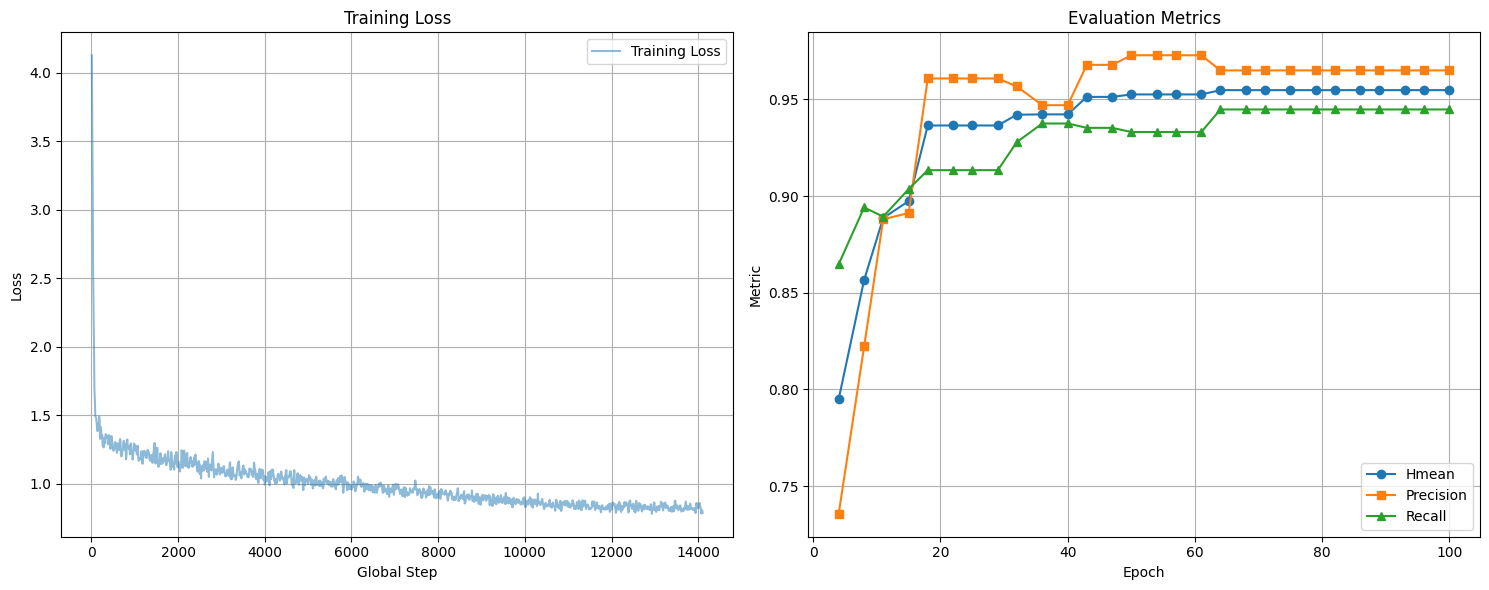

In [10]:
visualize_training_log(LOG_PATH, "train_log.png")

### Export Model

In [ ]:
%%capture
!python3 PaddleOCR/tools/infer/predict_det.py \
    --image_dir="{TEST_IMG_DIR}" \
    --det_model_dir="{INFER_MODEL_DIR}" \
    --det_algorithm="DB" \
    --use_gpu=True \
    --draw_img_save_dir="./inference_results/"

### Top 3 Worst and Best Test

In [ ]:
import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
from shapely.geometry import Polygon

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(os.path.join(OUTPUT_DIR, "best"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "worst"), exist_ok=True)

In [ ]:
def load_predictions(file_path):
    preds = {}
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return preds
        
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            img_name = os.path.basename(parts[0])
            try:
                # Format: Image.jpg \t [[[x,y],...], [[x,y],...]]
                boxes = json.loads(parts[1])
                preds[img_name] = [np.array(b, dtype=np.float32) for b in boxes]
            except:
                print(f"Skipping bad line in pred: {parts[0]}")
    return preds

def load_ground_truth(file_path):
    gts = {}
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return gts

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            img_name = os.path.basename(parts[0])
            try:
                data = json.loads(parts[1])
                # Format GT: [{"transcription": "...", "points": [[x,y],...]}, ...]
                boxes = [np.array(item['points'], dtype=np.float32) for item in data]
                gts[img_name] = boxes
            except:
                print(f"Skipping bad line in GT: {parts[0]}")
    return gts

def compute_iou(box1, box2):
    try:
        poly1 = Polygon(box1).convex_hull
        poly2 = Polygon(box2).convex_hull
        
        if not poly1.is_valid or not poly2.is_valid:
            return 0.0
        
        inter_area = poly1.intersection(poly2).area
        union_area = poly1.area + poly2.area - inter_area
        
        if union_area == 0: return 0.0
        return inter_area / union_area
    except Exception:
        return 0.0

def evaluate_image(pred_boxes, gt_boxes, iou_thresh=0.5):
    """Calculate Precision, Recall, Hmean"""
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return 1.0, 1.0, 1.0 # Empty picture & Predict is empty (True)
    if len(pred_boxes) == 0:
        return 0.0, 0.0, 0.0 # Have text but can't predict (Recall = 0)
    if len(gt_boxes) == 0:
        return 0.0, 0.0, 0.0 # Haven't text but predict wrong (Precision = 0)

    matched_gt = [False] * len(gt_boxes)
    tp = 0
    
    for p_box in pred_boxes:
        best_iou = 0
        best_gt_idx = -1
        
        for i, g_box in enumerate(gt_boxes):
            if matched_gt[i]: continue
            
            iou = compute_iou(p_box, g_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i
        
        if best_iou >= iou_thresh:
            tp += 1
            matched_gt[best_gt_idx] = True

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    hmean = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, hmean

def visualize_top_k(results_list, k=5, title_prefix="", save_folder=None, is_show=False):
    if not results_list: return

    plt.figure(figsize=(20, 6 * len(results_list)))
    
    for idx, item in enumerate(results_list):
        img_name = item['image']
        img_path = os.path.join(TEST_IMG_DIR, img_name)
        
        if not os.path.exists(img_path):
            print(f"Cannot find image: {img_path}")
            continue
            
        img = cv2.imread(img_path)
        
        # Draw GT (Green - Bold line)
        cv2.polylines(img, [b.astype(np.int32) for b in item['gt_boxes']], isClosed=True, color=(0, 255, 0), thickness=2)
        
        # Draw Pred (Red - Thin line)
        if len(item['pred_boxes']) > 0:
            cv2.polylines(img, [b.astype(np.int32) for b in item['pred_boxes']], isClosed=True, color=(0, 0, 255), thickness=2)

        if save_folder:           
            save_name = f"{title_prefix}_{item['hmean']:.3f}_{img_name}"
            save_path = os.path.join(save_folder, save_name)
            cv2.imwrite(save_path, img)

        if is_show:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(results_list), 1, idx + 1)
            plt.imshow(img_rgb)
            plt.title(f"{title_prefix} #{idx+1}: {img_name}\nHmean: {item['hmean']:.4f} | Prec: {item['p']:.4f} | Rec: {item['r']:.4f}\n(Green=GT, Red=Pred)", fontsize=14, color='blue', loc='left')
            plt.axis('off')

    if is_show:
        plt.tight_layout()
        plt.show()

In [ ]:
PRED_PATH = "./inference_results/det_results.txt"
preds_data = load_predictions(PRED_PATH)
print(f"Loaded {len(preds_data)} predictions.")

gts_data = load_ground_truth(TEST_GT_PATH)
print(f"Loaded {len(gts_data)} ground truths.")

common_images = set(preds_data.keys()).intersection(set(gts_data.keys()))
print(f"Analyzing {len(common_images)} common images.")

Loaded 594 predictions.
Loaded 594 ground truths.
Analyzing 594 common images.


In [ ]:
eval_results = []

for img_name in common_images:
    p_boxes = preds_data[img_name]
    g_boxes = gts_data[img_name]
    
    p, r, hmean = evaluate_image(p_boxes, g_boxes)
    
    eval_results.append({
        'image': img_name,
        'p': p, 'r': r, 'hmean': hmean,
        'pred_boxes': p_boxes,
        'gt_boxes': g_boxes
    })

# Sort by Hmean
eval_results.sort(key=lambda x: x['hmean'])

# Get top K worst/best eval results
K = 3
worst_k = eval_results[:K]
best_k = eval_results[-K:][::-1]

TOP 3 WORST RESULTS (Lowest Hmean)
DVSKTT-4 Ban ky thuc luc_DVSKTT_ban_thuc_XV_80b.jpg: Hmean=0.0000 (P=0.00, R=0.00)
DVSKTT-3 Ban ky toan thu_DVSKTT_ban_toan_X_55b.jpg: Hmean=0.2143 (P=0.38, R=0.15)
DVSKTT-4 Ban ky thuc luc_DVSKTT_ban_thuc_XV_22b.jpg: Hmean=0.3636 (P=0.89, R=0.23)


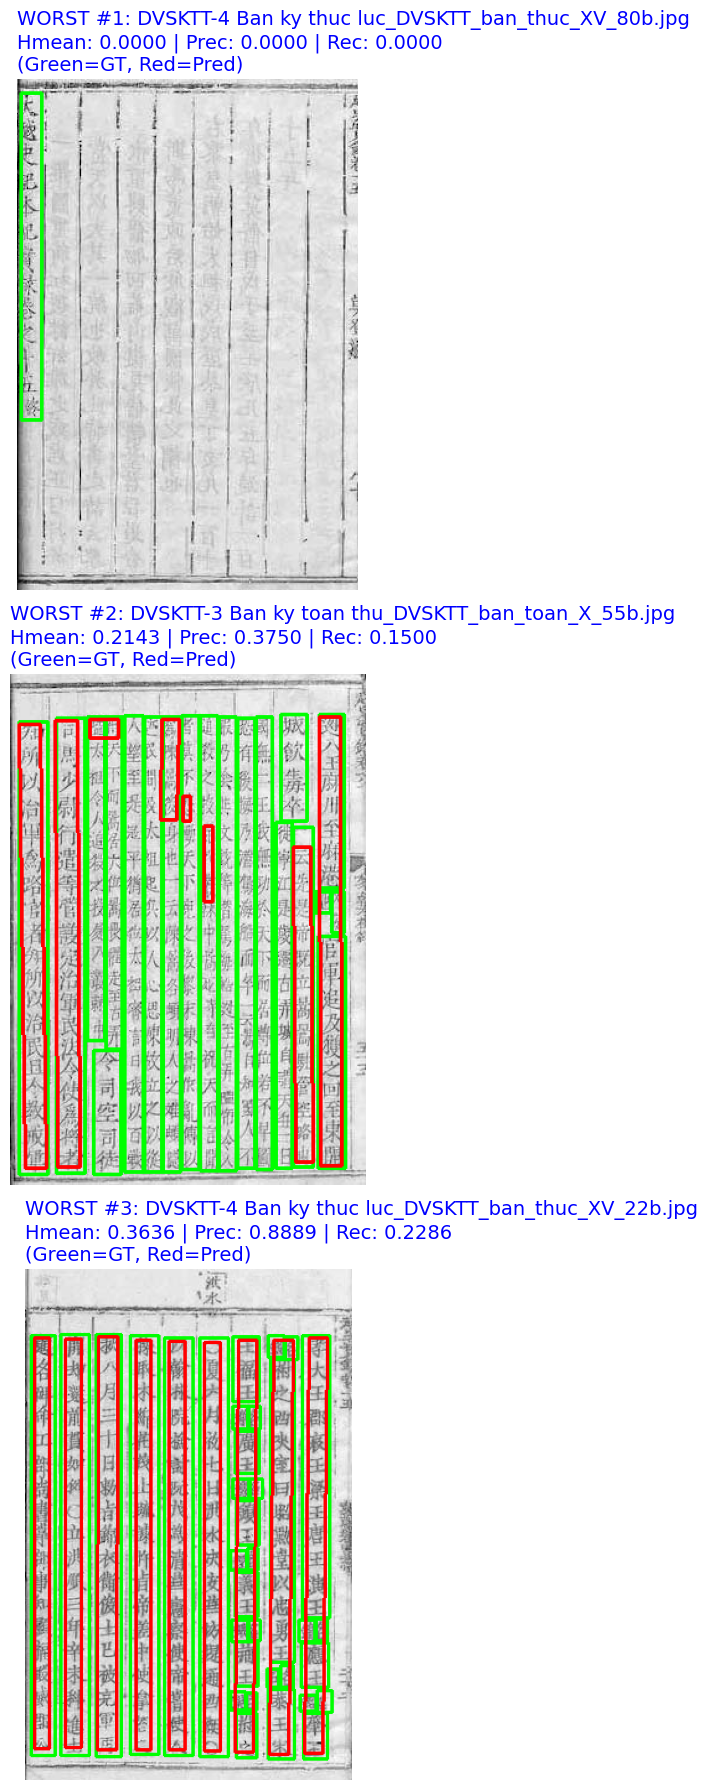

In [ ]:
print("="*30)
print(f"TOP {K} WORST RESULTS (Lowest Hmean)")
print("="*30)
for res in worst_k:
    print(f"{res['image']}: Hmean={res['hmean']:.4f} (P={res['p']:.2f}, R={res['r']:.2f})")
visualize_top_k(worst_k, k=K, title_prefix="WORST", save_folder=os.path.join(OUTPUT_DIR, "worst"), is_show=True)

TOP 3 BEST RESULTS (Highest Hmean)
DVSKTT-4 Ban ky thuc luc_DVSKTT_ban_thuc_XV_72a.jpg: Hmean=1.0000 (P=1.00, R=1.00)
DVSKTT-4 Ban ky thuc luc_DVSKTT_ban_thuc_XV_39a.jpg: Hmean=1.0000 (P=1.00, R=1.00)
DVSKTT-2 Ngoai ky toan thu_DVSKTT_ngoai_V_23b.jpg: Hmean=1.0000 (P=1.00, R=1.00)


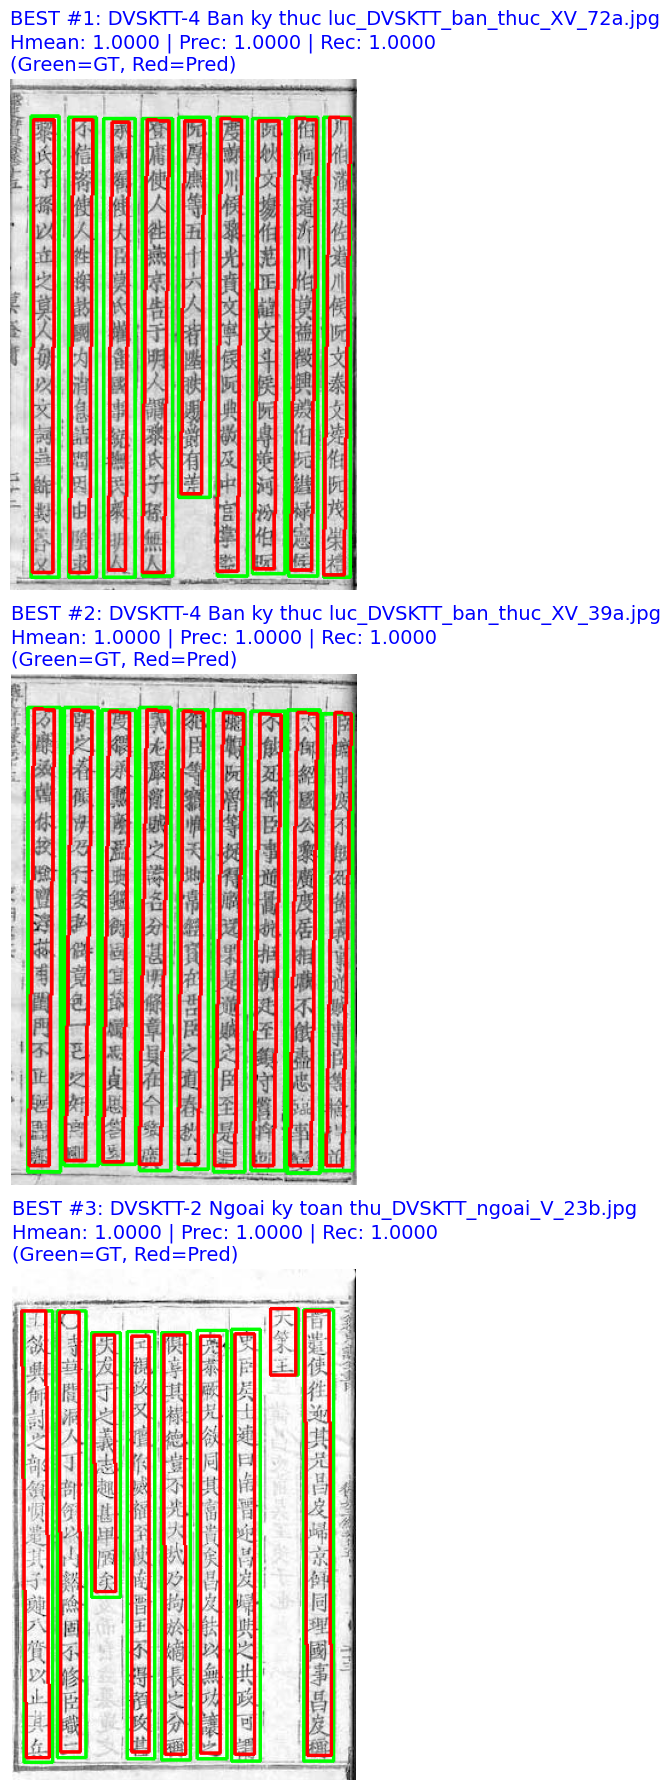

In [ ]:
print("="*30)
print(f"TOP {K} BEST RESULTS (Highest Hmean)")
print("="*30)
for res in best_k:
    print(f"{res['image']}: Hmean={res['hmean']:.4f} (P={res['p']:.2f}, R={res['r']:.2f})")
visualize_top_k(best_k, k=K, title_prefix="BEST", save_folder=os.path.join(OUTPUT_DIR, "best"), is_show=True)